In [ ]:
!pip install yfinance pandas numpy -q

In [ ]:
import os
import numpy as np
import pandas as pd
import yfinance as yf

# === Config ===
IBKR_HOST = "127.0.0.1"
IBKR_PORT = 7497
IBKR_CLIENT_ID = 1

RAW_DATA_DIR = "data/raw"
PROCESSED_DATA_DIR = "data/processed"

SPX_YF_TICKER = "^GSPC"
START_DATE = "2005-01-01"
END_DATE = "2025-12-31"

HAR_HORIZONS = [1, 5, 22]
TARGET_FORWARD_WINDOW = 22
SPIKE_PERCENTILE = 90

os.makedirs(RAW_DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)


In [ ]:
def fetch_spx_daily() -> pd.DataFrame:
    """Download SPX daily OHLCV from Yahoo Finance."""
    path = os.path.join(RAW_DATA_DIR, "spx_daily.csv")
    if os.path.exists(path):
        print(f"  [cache] Loading {path}")
        return pd.read_csv(path, index_col="Date", parse_dates=True)

    print("  Downloading SPX daily from Yahoo Finance...")
    df = yf.download(SPX_YF_TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
    df.to_csv(path)
    print(f"  Saved -> {path}  ({len(df)} rows)")
    return df


def compute_daily_rv(close: pd.Series) -> pd.DataFrame:
    """Compute realized vol at 1d, 5d, 22d horizons from daily close-to-close returns."""
    log_ret = np.log(close / close.shift(1))
    squared = log_ret ** 2

    rv = pd.DataFrame(index=close.index)
    for h in HAR_HORIZONS:
        rv[f"RV_{h}d"] = np.sqrt(squared.rolling(h).sum() * (252 / h))
    return rv.dropna()


def build_targets(close: pd.Series) -> pd.DataFrame:
    """
    Regression target: 22-day forward realized vol.
    Classification target: spike = 1 if fwd RV > 90th percentile.
    """
    log_ret = np.log(close / close.shift(1))
    squared = log_ret ** 2

    fwd_rv = []
    sq = squared.values
    for i in range(len(sq)):
        end = i + 1 + TARGET_FORWARD_WINDOW
        if end > len(sq):
            fwd_rv.append(np.nan)
        else:
            fwd_rv.append(np.sqrt(np.sum(sq[i+1:end]) * (252 / TARGET_FORWARD_WINDOW)))

    targets = pd.DataFrame({"fwd_rv_22d": fwd_rv}, index=close.index).dropna()

    if len(targets) == 0:
        print("  [warn] No target data — is SPX data empty?")
        targets["spike_label"] = pd.Series(dtype=int)
        return targets

    threshold = np.percentile(targets["fwd_rv_22d"], SPIKE_PERCENTILE)
    targets["spike_label"] = (targets["fwd_rv_22d"] > threshold).astype(int)
    print(f"  Spike threshold (p{SPIKE_PERCENTILE}): {threshold:.4f}")
    print(f"  Spikes: {targets['spike_label'].sum()} / {len(targets)}")
    return targets


In [ ]:
print("=" * 60)
print("P5 — HAR-RV Baseline + Target Construction")
print("=" * 60)

# Download SPX daily
spx = fetch_spx_daily()
close = spx["Close"].squeeze()

# Realized vol features (daily proxy — no IBKR in Colab)
print("\nComputing realized volatility (daily close-to-close proxy)...")
rv = compute_daily_rv(close)
rv.to_csv(os.path.join(PROCESSED_DATA_DIR, "har_rv_features.csv"))
print(f"  Saved har_rv_features.csv  ({len(rv)} rows)")

# Target variable
print("\nBuilding target variable...")
targets = build_targets(close)
targets.to_csv(os.path.join(PROCESSED_DATA_DIR, "targets.csv"))
print(f"  Saved targets.csv  ({len(targets)} rows)")

print("\nDone!")


P5 — HAR-RV Baseline + Target Construction


[*********************100%***********************]  1 of 1 completed


  Saved -> data/raw/spx_daily.csv  (5282 rows)

Computing realized volatility (daily close-to-close proxy)...
  Saved har_rv_features.csv  (5260 rows)

Building target variable...
  Spike threshold (p90): 0.2626
  Spikes: 526 / 5260
  Saved targets.csv  (5260 rows)

Done!


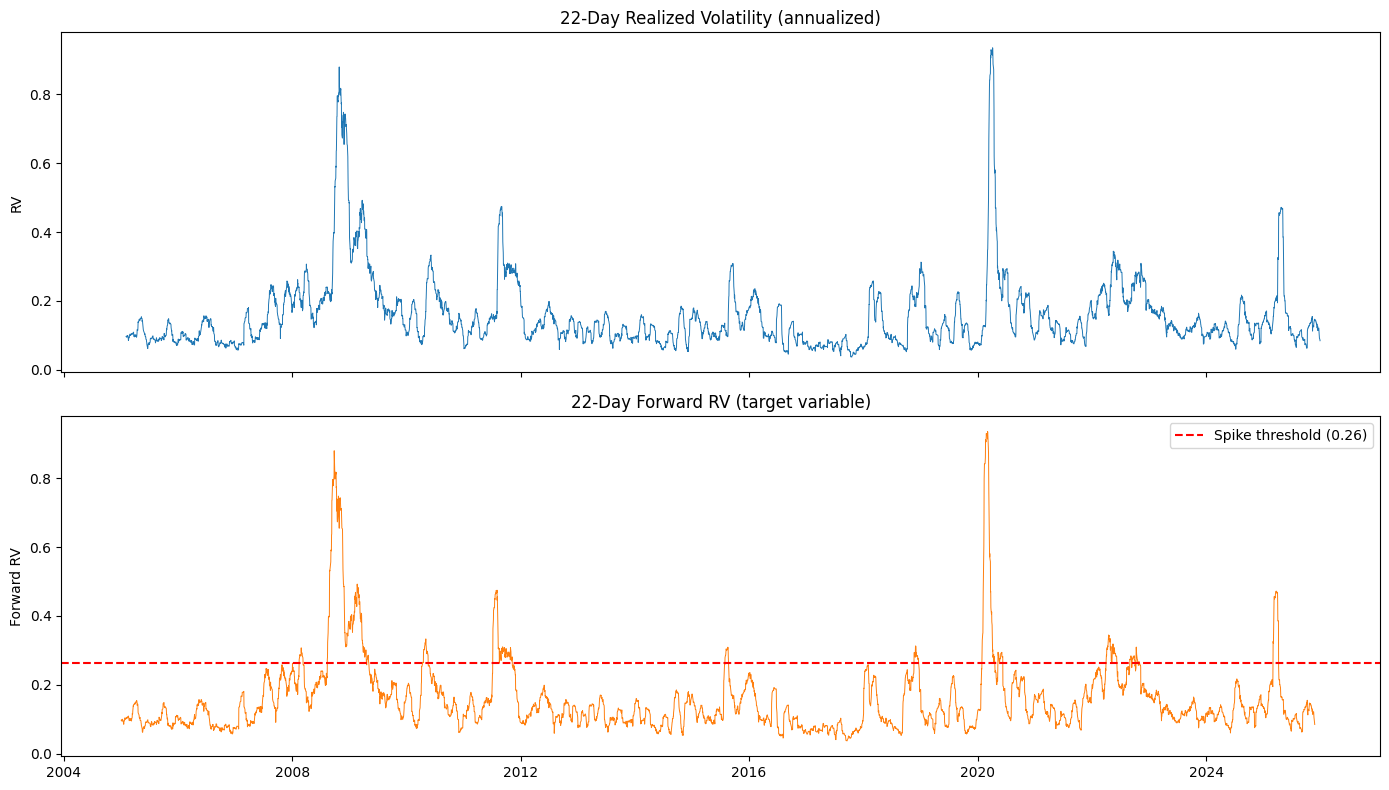


Spike distribution: {0: 4734, 1: 526}


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(rv.index, rv["RV_22d"], linewidth=0.7)
axes[0].set_title("22-Day Realized Volatility (annualized)")
axes[0].set_ylabel("RV")

threshold = targets["fwd_rv_22d"].quantile(0.9)
axes[1].plot(targets.index, targets["fwd_rv_22d"], linewidth=0.7, color="tab:orange")
axes[1].axhline(threshold, color="red", linestyle="--", label=f"Spike threshold ({threshold:.2f})")
axes[1].set_title("22-Day Forward RV (target variable)")
axes[1].set_ylabel("Forward RV")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nSpike distribution: {targets['spike_label'].value_counts().to_dict()}")
